### Analysis of deconvoluted 10X Visium Bleo day21 data

ST data from [Franzen, Lindvall, et al. Nature Genetics (2024)](https://www.nature.com/articles/s41588-024-01819-2)

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sb

In [2]:
import cell2location as c2l

/home/niklas/miniconda3/envs/c2l_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# making sure plots & clusters are reproducible
np.random.seed(42)

In [4]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig_spatial_overview/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [5]:
## path variables
spatial_dir = '/mnt/smb/Niklas/20240911_10XVisum_Stockholm_mouse/'
fig_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig_spatial_overview/'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'

In [6]:
## paths reference regression and cell2location models
ref_run_name = f'{spatial_dir}/reference_signatures'
run_name = f'{spatial_dir}/cell2location_map'

### Load Visium data

In [7]:
adata_file = f'{run_name}/250111_10XVisium_d21_deconvolution.h5ad'

In [8]:
adata_st = sc.read(adata_file)

In [9]:
adata_st

AnnData object with n_obs × n_vars = 23107 × 11916
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', '_indices', '_scvi_batch', '_scvi_labels', 'AT1', 'AT2', 'AT2 activated', 'Krt8+ ADI', 'Basal', 'Club/Ciliated', 'Ciliated', 'NEC', 'Aerocyte capillary EC', 'Transitional capillary EC', 'General capillary EC', 'Proliferating capillary EC', 'Vwa1+/Col15a1+ ectopic capillary EC', 'Arterial EC', 'Venous EC', 'Lymphatic EC', 'Adventitial Fibroblasts', 'Adh7+ Fibroblasts', 'Lgr5+/Lgr6+ Fibroblasts', 'Lgr5+/Lgr6+ Fibroblasts activated', 'Lipofibroblasts', 'Lipo/Myofibroblast Transition', 'Cthrc1+ Myofibroblasts', 'Spp1+ Myofibroblasts', 'Pericytes', 'Pericytes activated', 'aSMCs', 'vSMCs', 'Mesothelial', 'Non-classical Monocytes', 'Classical Monocytes', 'Intermediate M

### Load metadata

In [10]:
metadata_file = f'{spatial_dir}/mm_visium_metadata.tsv'

In [11]:
metadata = pd.read_csv(metadata_file, sep = '\t')
metadata.head(5)

,sample_name,sample_id,slide_id,slide_ca,day,condition,group,animal,replicate,tissue,lobe,species
0,d7_ctrl_1,V10A20-072-A1,V10A20-072,A1,d7,control,d7_CTRL,d7_c1,a,lung,left,mouse
1,d7_ctrl_2,V10A20-074-A1,V10A20-074,A1,d7,control,d7_CTRL,d7_c2,a,lung,left,mouse
2,d7_ctrl_3,V10A20-073-A1,V10A20-073,A1,d7,control,d7_CTRL,d7_c3,a,lung,left,mouse
3,d7_bleo_1,V10A20-072-B1,V10A20-072,B1,d7,bleomycin,d7_BLM,d7_b1,a,lung,left,mouse
4,d7_bleo_2,V10A20-072-C1,V10A20-072,C1,d7,bleomycin,d7_BLM,d7_b2,a,lung,left,mouse


In [12]:
metadata = metadata[(metadata['day'] == 'd21') & (metadata['sample_name'].isin(['d21_ctrl_1','d21_ctrl_2','d21_ctrl_3','d21_bleo_4b','d21_bleo_5b','d21_bleo_6b']))]
metadata.head(6)

,sample_name,sample_id,slide_id,slide_ca,day,condition,group,animal,replicate,tissue,lobe,species
12,d21_ctrl_1,V10A20-071-A1,V10A20-071,A1,d21,control,d21_CTRL,d21_c1,a,lung,left,mouse
13,d21_ctrl_2,V10A20-052-A1,V10A20-052,A1,d21,control,d21_CTRL,d21_c2,a,lung,left,mouse
14,d21_ctrl_3,V10A20-053-A1,V10A20-053,A1,d21,control,d21_CTRL,d21_c3,a,lung,left,mouse
21,d21_bleo_4b,V10A20-053-B1,V10A20-053,B1,d21,bleomycin,d21_BLM,d21_b4,b,lung,left,mouse
22,d21_bleo_5b,V10A20-053-C1,V10A20-053,C1,d21,bleomycin,d21_BLM,d21_b5,b,lung,left,mouse
23,d21_bleo_6b,V10A20-053-D1,V10A20-053,D1,d21,bleomycin,d21_BLM,d21_b6,b,lung,left,mouse


### Correlogram of cell type abundancies across spots in fibrotic slides

In [13]:
## get abundancies
abundance_df = adata_st.obsm['q05_cell_abundance_w_sf']
abundance_df.head(5)

,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_AT2,q05cell_abundance_w_sf_AT2 activated,q05cell_abundance_w_sf_Krt8+ ADI,q05cell_abundance_w_sf_Basal,q05cell_abundance_w_sf_Club/Ciliated,q05cell_abundance_w_sf_Ciliated,q05cell_abundance_w_sf_NEC,q05cell_abundance_w_sf_Aerocyte capillary EC,q05cell_abundance_w_sf_Transitional capillary EC,...,q05cell_abundance_w_sf_Cd4+ T cells,q05cell_abundance_w_sf_Cd8+ T cells,q05cell_abundance_w_sf_Cd4+/Cd8+ T cells,q05cell_abundance_w_sf_T reg cells,q05cell_abundance_w_sf_Th2 cells,q05cell_abundance_w_sf_Th17 cells,q05cell_abundance_w_sf_Themis+ T cells,q05cell_abundance_w_sf_Proliferating T cells,q05cell_abundance_w_sf_NK T cells,q05cell_abundance_w_sf_NK cells
spot_id,,,,,,,,,,,,,,,,,,,,,
V10A20-071-A1_AAACAATCTACTAGCA-1,4.113769,1.139344,0.366584,0.152523,0.140346,0.514938,0.230613,0.285543,1.004229,2.369811,...,0.105918,0.319765,0.097983,0.104582,0.099392,0.062116,0.086508,0.089139,0.083946,0.076569
V10A20-071-A1_AAACACCAATAACTGC-1,1.985945,0.893109,0.155001,0.247543,0.551929,1.831060,0.575216,0.042521,0.255931,0.946755,...,0.124810,0.886896,0.127265,0.073109,0.087379,0.053119,0.094364,0.031817,0.087758,0.183758
V10A20-071-A1_AAACAGAGCGACTCCT-1,3.724804,0.808966,0.136281,0.114779,0.323484,0.109360,0.014716,0.042559,0.379324,1.368024,...,0.078115,0.216633,0.062395,0.088471,0.058415,0.111647,0.039536,0.045233,0.049074,0.040001
V10A20-071-A1_AAACAGCTTTCAGAAG-1,1.955670,1.088263,0.265530,0.313392,1.006302,2.186129,1.191127,0.014109,0.520178,1.044697,...,0.085978,0.902439,0.086662,0.055918,0.076222,0.042772,0.044281,0.121479,0.043865,0.044904
V10A20-071-A1_AAACAGGGTCTATATT-1,4.047786,1.012169,0.190994,0.088427,0.279707,0.678788,0.394819,0.257603,0.440241,1.343747,...,0.078758,0.247904,0.069661,0.089210,0.081454,0.051439,0.083150,0.028412,0.060418,0.074271


In [14]:
## clean col names
abundance_df.columns = abundance_df.columns.str.replace('^q05cell_abundance_w_sf_', '', regex=True)
abundance_df.head(5)

,AT1,AT2,AT2 activated,Krt8+ ADI,Basal,Club/Ciliated,Ciliated,NEC,Aerocyte capillary EC,Transitional capillary EC,...,Cd4+ T cells,Cd8+ T cells,Cd4+/Cd8+ T cells,T reg cells,Th2 cells,Th17 cells,Themis+ T cells,Proliferating T cells,NK T cells,NK cells
spot_id,,,,,,,,,,,,,,,,,,,,,
V10A20-071-A1_AAACAATCTACTAGCA-1,4.113769,1.139344,0.366584,0.152523,0.140346,0.514938,0.230613,0.285543,1.004229,2.369811,...,0.105918,0.319765,0.097983,0.104582,0.099392,0.062116,0.086508,0.089139,0.083946,0.076569
V10A20-071-A1_AAACACCAATAACTGC-1,1.985945,0.893109,0.155001,0.247543,0.551929,1.831060,0.575216,0.042521,0.255931,0.946755,...,0.124810,0.886896,0.127265,0.073109,0.087379,0.053119,0.094364,0.031817,0.087758,0.183758
V10A20-071-A1_AAACAGAGCGACTCCT-1,3.724804,0.808966,0.136281,0.114779,0.323484,0.109360,0.014716,0.042559,0.379324,1.368024,...,0.078115,0.216633,0.062395,0.088471,0.058415,0.111647,0.039536,0.045233,0.049074,0.040001
V10A20-071-A1_AAACAGCTTTCAGAAG-1,1.955670,1.088263,0.265530,0.313392,1.006302,2.186129,1.191127,0.014109,0.520178,1.044697,...,0.085978,0.902439,0.086662,0.055918,0.076222,0.042772,0.044281,0.121479,0.043865,0.044904
V10A20-071-A1_AAACAGGGTCTATATT-1,4.047786,1.012169,0.190994,0.088427,0.279707,0.678788,0.394819,0.257603,0.440241,1.343747,...,0.078758,0.247904,0.069661,0.089210,0.081454,0.051439,0.083150,0.028412,0.060418,0.074271


### Calculate and filter correlation matrix

In [15]:
## select only cell type robustly represented in single cell data - read data
ct_variance = pd.read_csv(data_dir + '250130_cell_type_abundance_per_sampe.csv', sep=',', index_col=0)
ct_variance.head(5)

,d10BLM9,d10BLM10,d10BLM11,d10BLM12,d10BLM13,d10BLM14,d10BLM15,d10BLM16,d10BLM_Combo39,d10BLM_Combo41,...,d100BLM_G169038,d100BLM_Nint58,d210BLMCombo124,d210BLMG1690110,d210BLM_G120596,d210BLM_Nint139,mean,std,ci_5pct,ci_95pct
cell_type,,,,,,,,,,,,,,,,,,,,,
AT1,8,1,1,1,11,19,17,22,1,0,...,4,2,7,1,12,13,8.4,7.6,7.0,9.8
AT2,0,0,0,0,0,3,0,0,0,0,...,0,0,0,2,0,4,26.5,61.4,14.8,38.2
AT2 activated,1,1,6,1,1,23,15,4,0,4,...,7,25,4,15,7,50,11.8,12.8,9.4,14.2
Krt8+ ADI,30,10,14,29,55,19,24,69,7,22,...,11,28,9,2,5,9,18.9,18.6,15.4,22.4
Basal,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1.0,2.1,0.6,1.4


In [16]:
## select only cell type robustly represented in single cell data - do the actual filtering

## several ways to do this, e.g. see below
## cell type detected in at least X samples
## cell type detected in at least X samples per treatment 
## X cell of this cell type detected in per sample

## our approach: cell type with non-zero count in fewer than 25 samples
## our rationale: we have max. 18 samples per treatment, if we have full depletion or disease-specificity of one cell type we still want to include it, while also accounting for some variability/dropout, so threshold has to be higher

robust_ct = []

for ct in ct_variance.index.to_list():
    n_zeros = sum(ct_variance.loc[ct,:] == 0)
    print(f'{ct} not detected in {n_zeros} samples')
    if n_zeros < 25:
        robust_ct.append(ct)

AT1 not detected in 12 samples
AT2 not detected in 63 samples
AT2 activated not detected in 5 samples
Krt8+ ADI not detected in 13 samples
Basal not detected in 74 samples
Club/Ciliated not detected in 29 samples
Ciliated not detected in 0 samples
NEC not detected in 77 samples
Aerocyte capillary EC not detected in 0 samples
Transitional capillary EC not detected in 14 samples
General capillary EC not detected in 0 samples
Proliferating capillary EC not detected in 32 samples
Vwa1+/Col15a1+ ectopic capillary EC not detected in 1 samples
Arterial EC not detected in 0 samples
Venous EC not detected in 0 samples
Lymphatic EC not detected in 10 samples
Adventitial Fibroblasts not detected in 9 samples
Adh7+ Fibroblasts not detected in 20 samples
Lgr5+/Lgr6+ Fibroblasts not detected in 42 samples
Lgr5+/Lgr6+ Fibroblasts activated not detected in 41 samples
Lipofibroblasts not detected in 2 samples
Lipo/Myofibroblast Transition not detected in 12 samples
Cthrc1+ Myofibroblasts not detected i

In [17]:
print(robust_ct)

['AT1', 'AT2 activated', 'Krt8+ ADI', 'Ciliated', 'Aerocyte capillary EC', 'Transitional capillary EC', 'General capillary EC', 'Vwa1+/Col15a1+ ectopic capillary EC', 'Arterial EC', 'Venous EC', 'Lymphatic EC', 'Adventitial Fibroblasts', 'Adh7+ Fibroblasts', 'Lipofibroblasts', 'Lipo/Myofibroblast Transition', 'Cthrc1+ Myofibroblasts', 'Pericytes', 'Pericytes activated', 'vSMCs', 'Non-classical Monocytes', 'Classical Monocytes', 'Intermediate Monocytes', 'Transitional Monocytes', 'M2 Macrophages', 'AM', 'Proliferating AM', 'Lyve1+/Cd163+ IM', 'Lyve1-/Cd163- IM', 'cDC1', 'cDC2', 'pDC', 'Proliferating cDC1', 'Proliferating cDC2', 'Megakaryocytes', 'Eosinophils', 'Immature Neutrophils', 'Mature Neutrophils', 'B cells', 'Cd4+ T cells', 'Cd8+ T cells', 'Cd4+/Cd8+ T cells', 'T reg cells', 'Th2 cells', 'Th17 cells', 'Proliferating T cells', 'NK T cells', 'NK cells']


In [18]:
abundance_df = abundance_df[robust_ct]

In [19]:
## compute correlation matrix
corr_matrix = abundance_df.corr(method='pearson')

## Visualization

<Figure size 1920x1920 with 0 Axes>

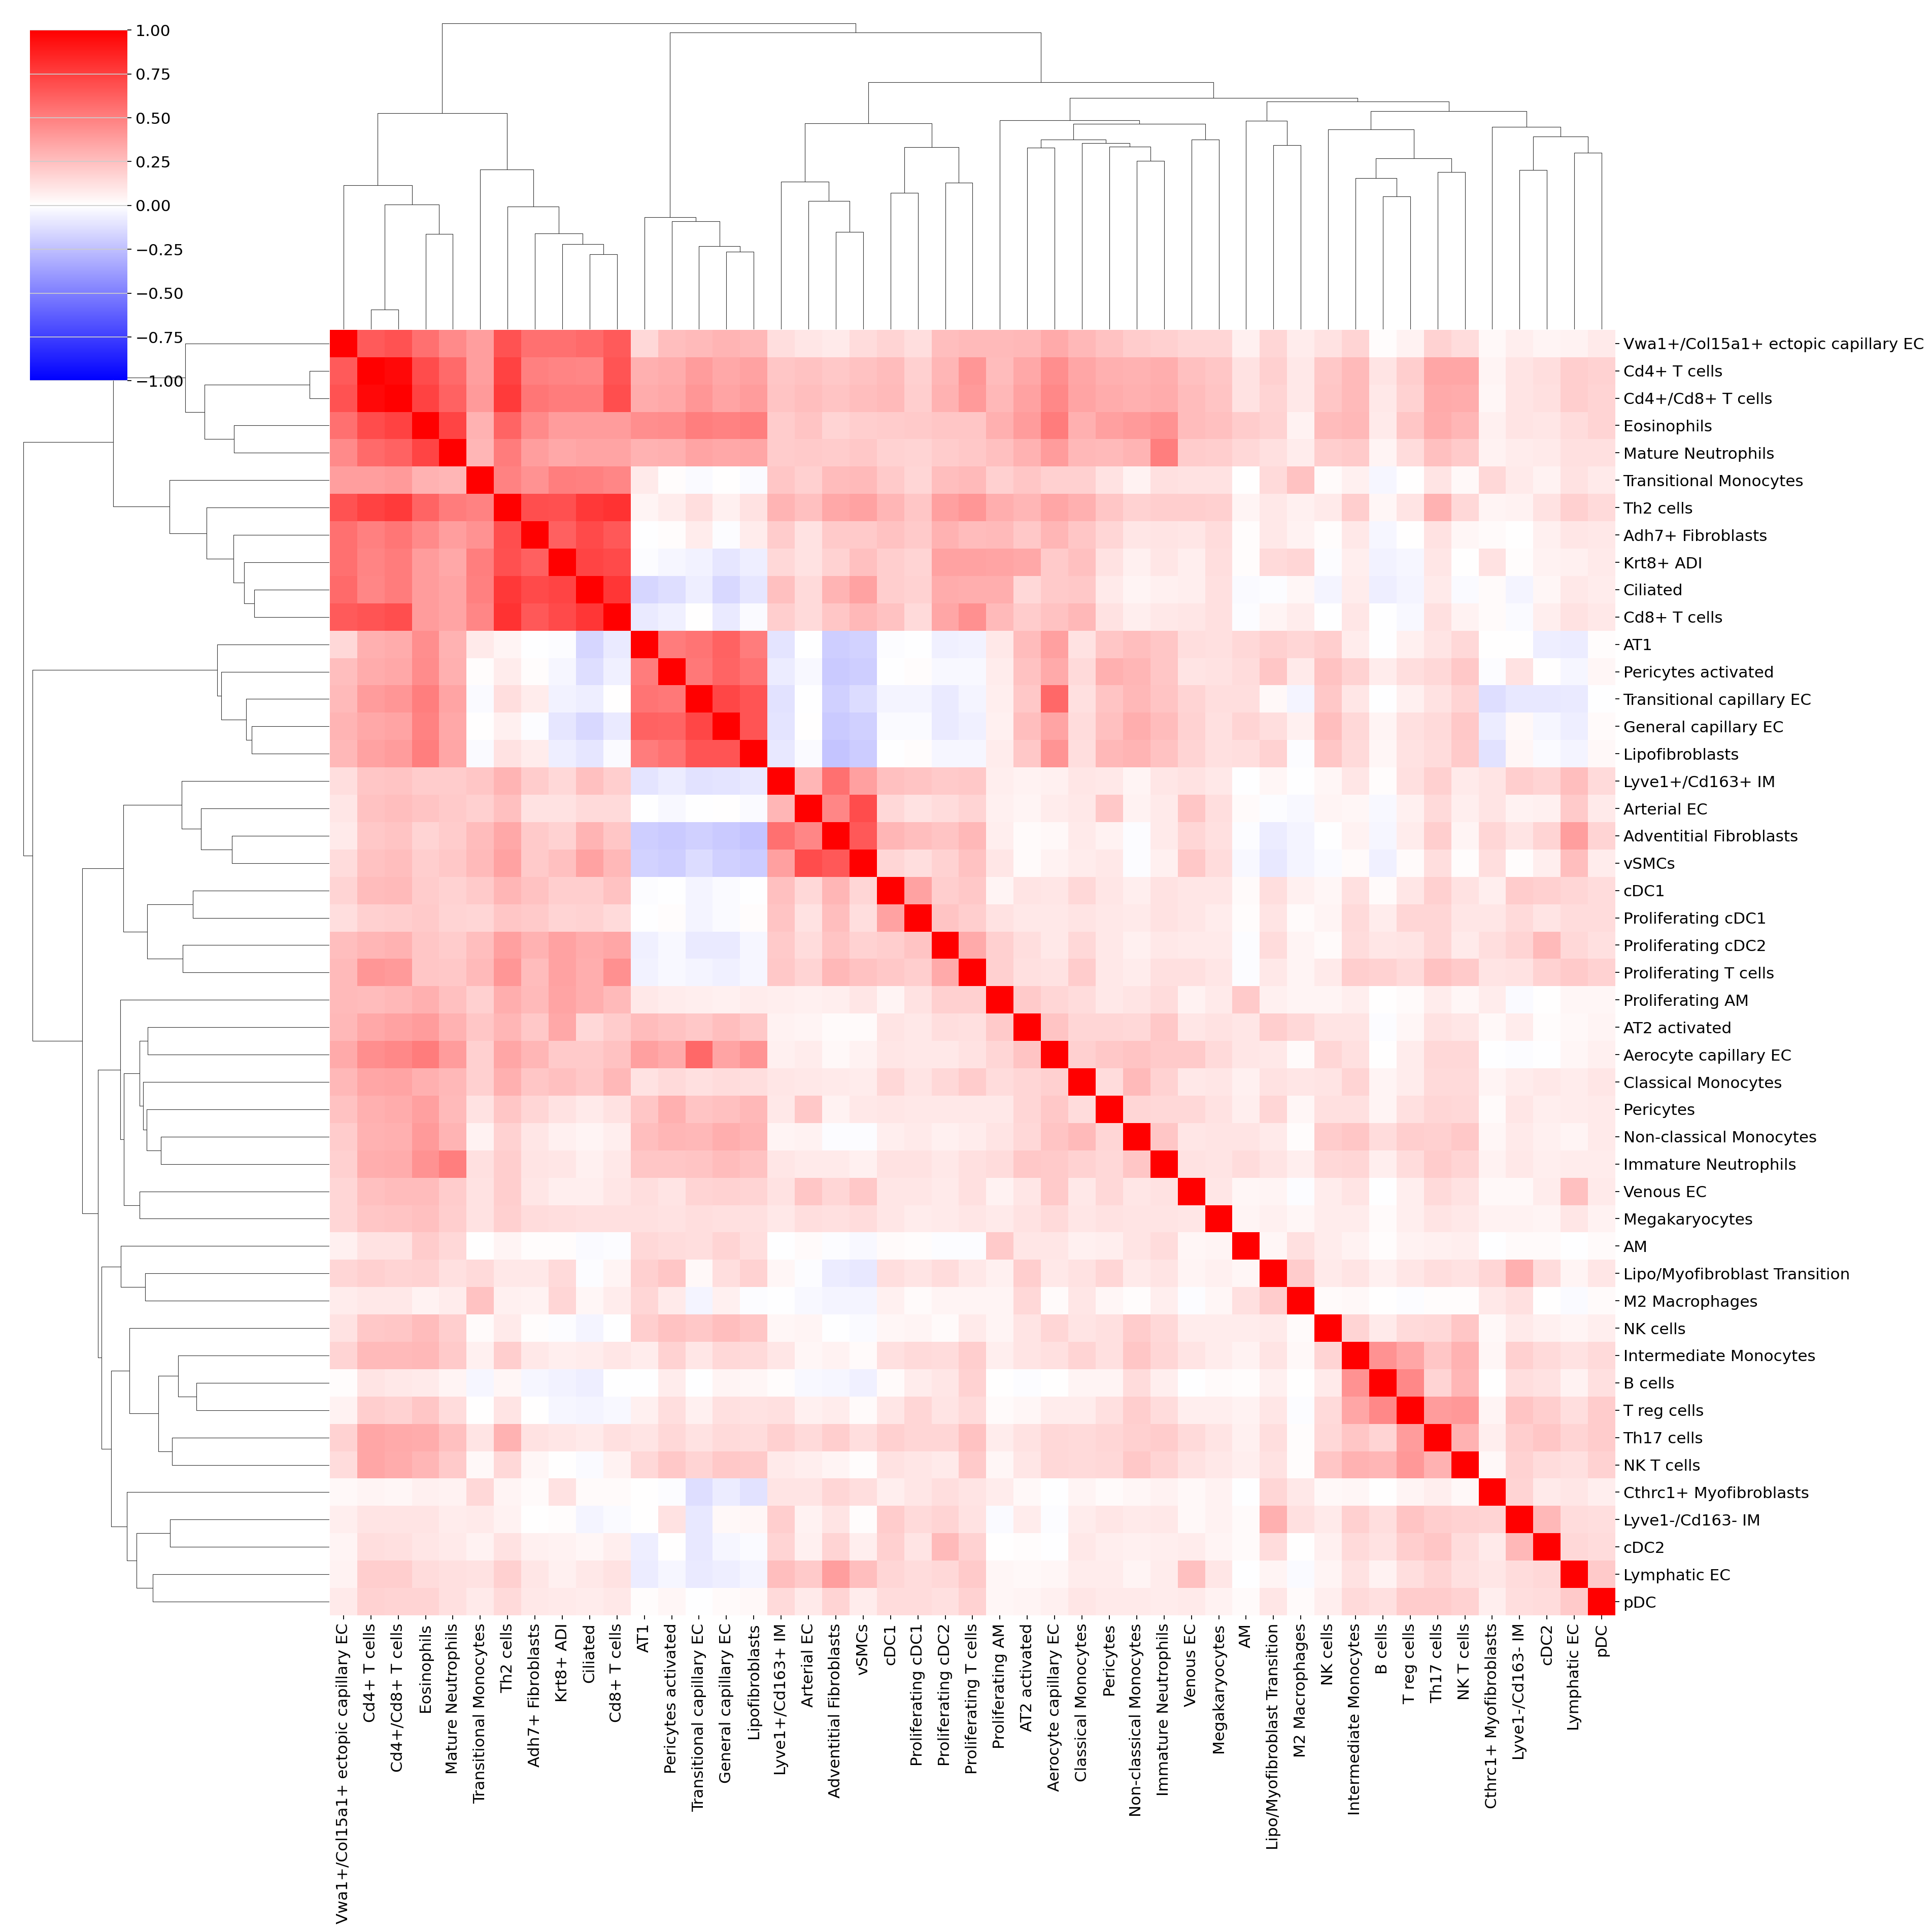

In [20]:
## correlogram 
plt.figure(figsize=(24, 24))
g = sb.clustermap(corr_matrix,
                  method='average',
                  metric='euclidean',
                  cmap='bwr',
                  vmin=-1, vmax=1,
                  center=0,
                  linewidths=0,
                  linecolor=None, 
                  figsize=(24, 24)
                 )
g.ax_heatmap.grid(False)
g.savefig(fig_dir + 'cell2location_filtered_correlogram_pearson_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

<Figure size 1920x1920 with 0 Axes>

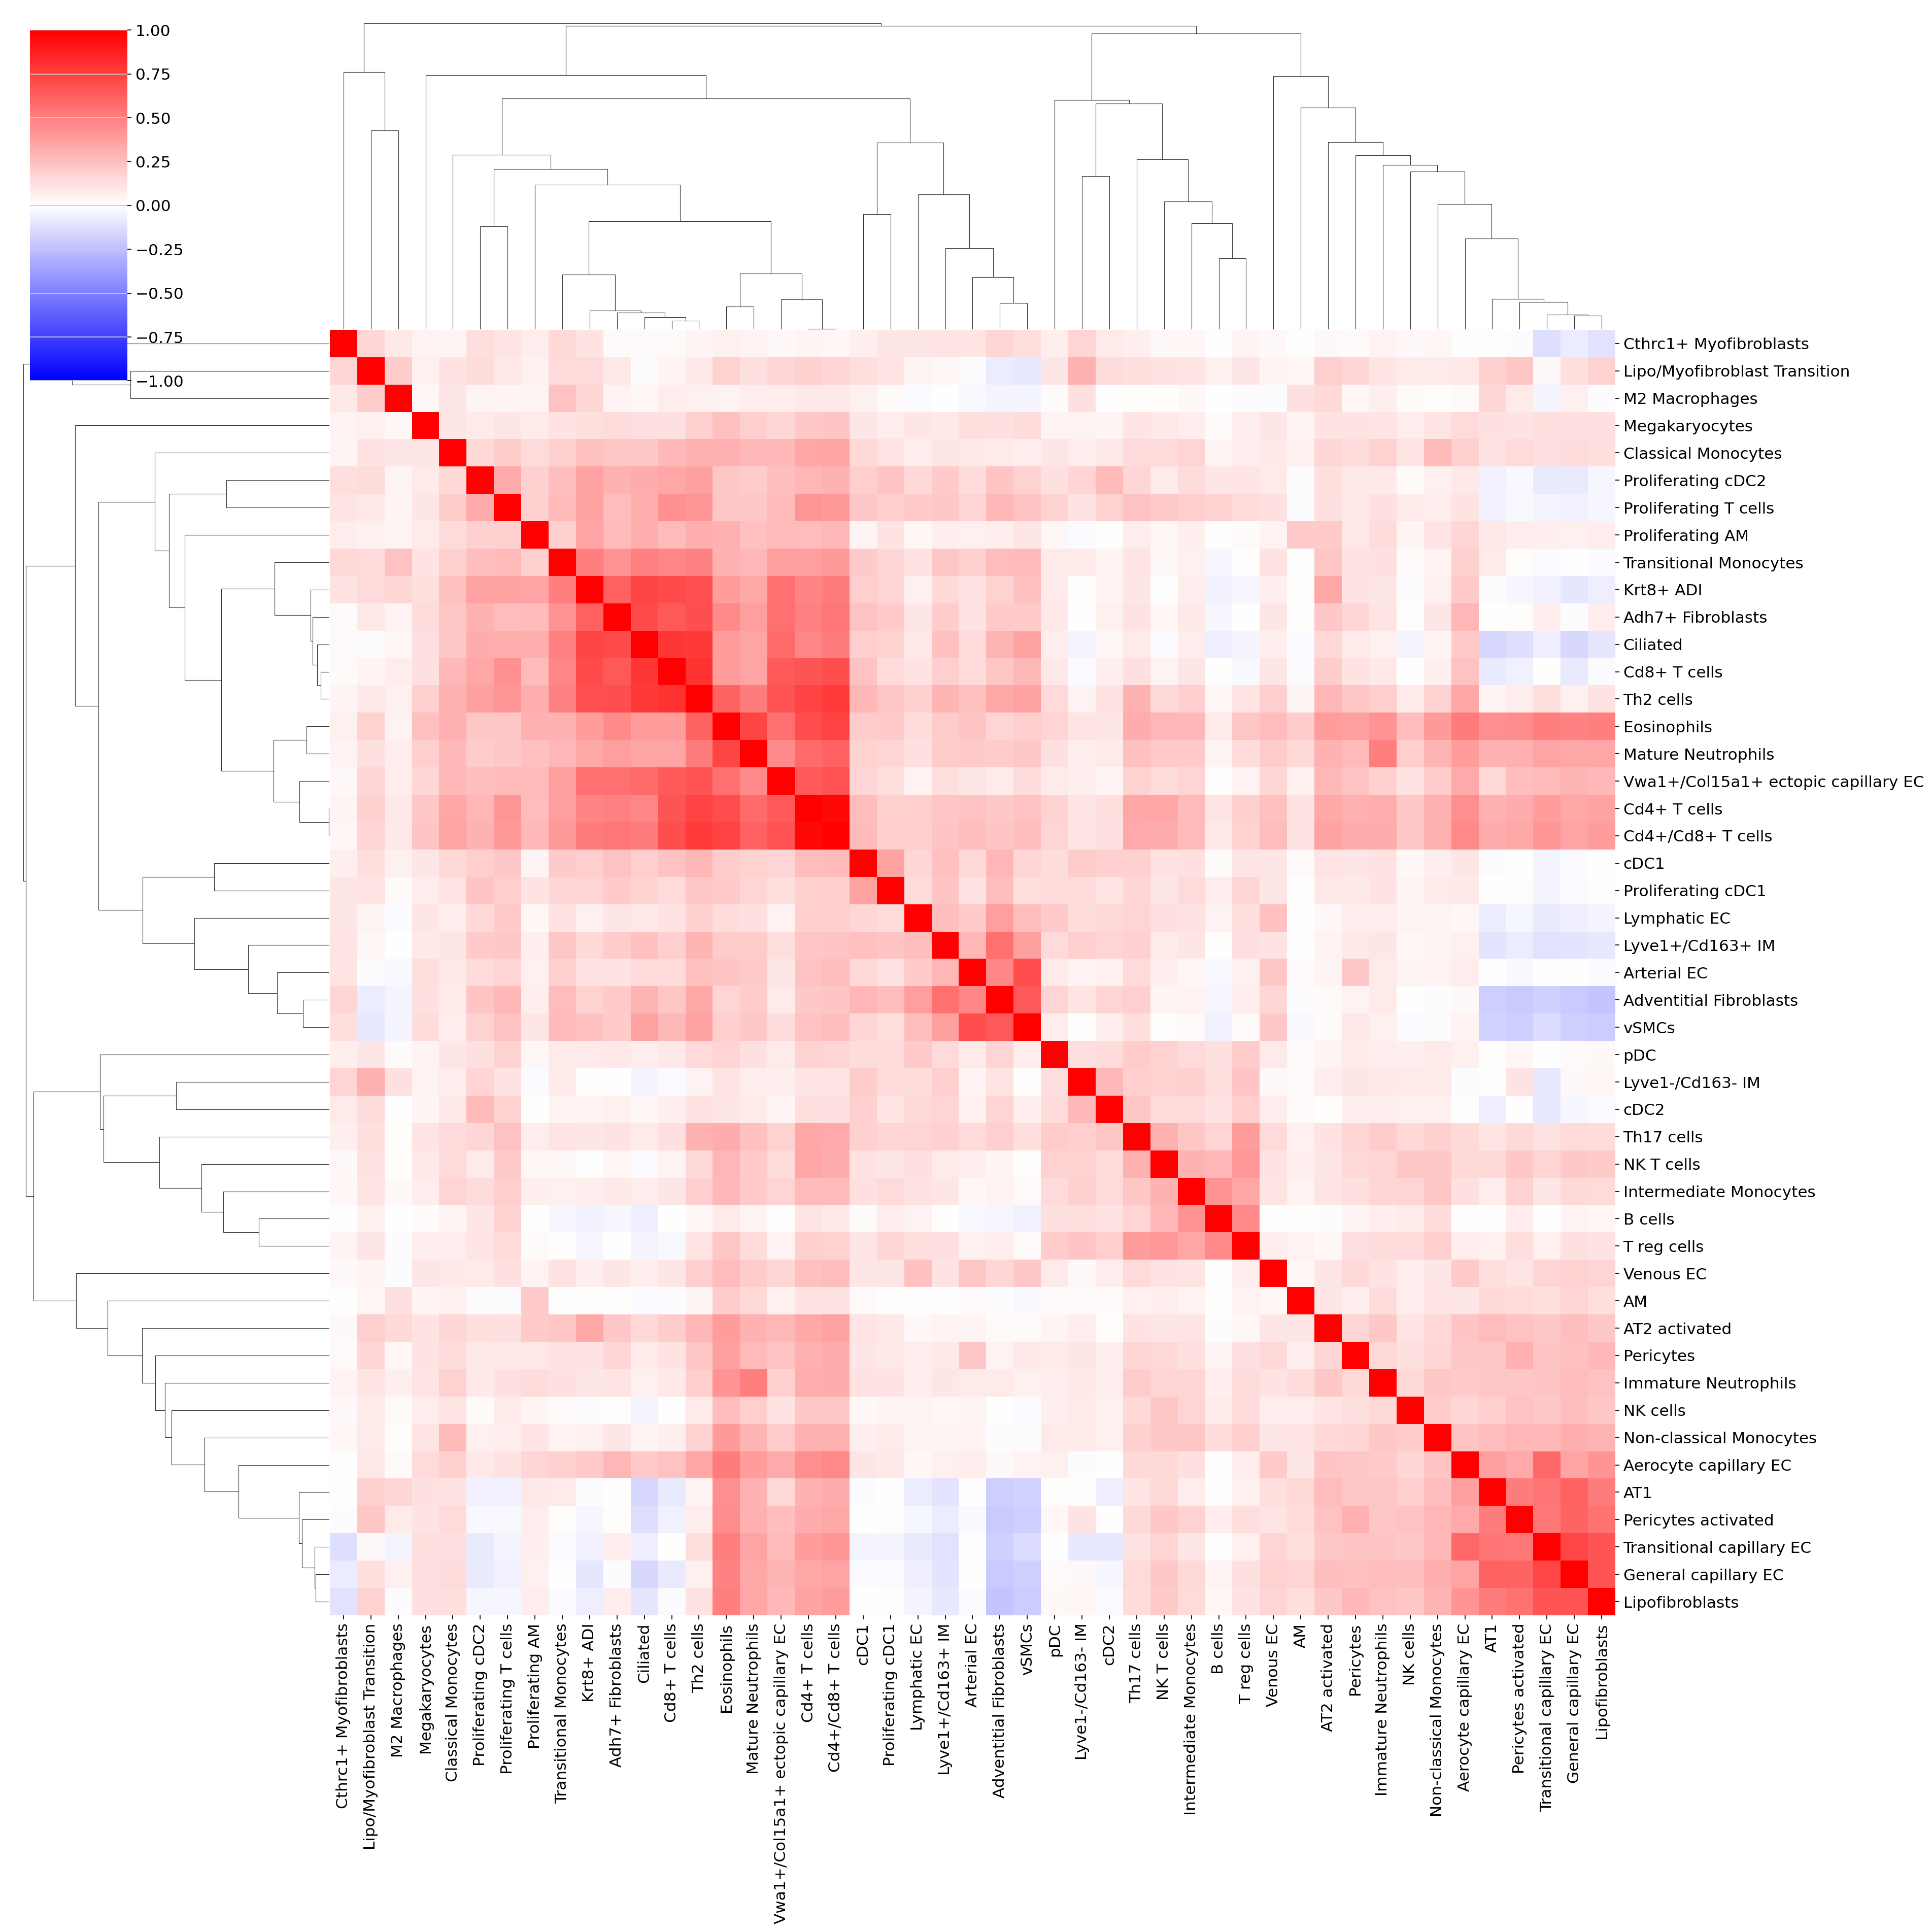

In [21]:
## correlogram 
plt.figure(figsize=(24, 24))
g = sb.clustermap(corr_matrix,
                  method='average',
                  metric='correlation',
                  cmap='bwr',
                  vmin=-1, vmax=1,
                  center=0,
                  linewidths=0,
                  linecolor=None, 
                  figsize=(24, 24)
                 )
g.ax_heatmap.grid(False)
g.savefig(fig_dir + 'cell2location_filtered_correlogram_pearson_2.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [22]:
corr_matrix[corr_matrix['Eosinophils'] > 0.5]['Eosinophils'].sort_values(ascending=False)

Eosinophils                            1.000000
Cd4+/Cd8+ T cells                      0.742098
Mature Neutrophils                     0.729469
Cd4+ T cells                           0.698592
Th2 cells                              0.604454
Vwa1+/Col15a1+ ectopic capillary EC    0.561917
Aerocyte capillary EC                  0.507885
Lipofibroblasts                        0.503726
Transitional capillary EC              0.502004
Name: Eosinophils, dtype: float64

In [23]:
## disease associated cell states
cell_types_of_interest = ['T reg cells',
                          'Lipo/Myofibroblast Transition',
                          'Proliferating AM',
                          'Cthrc1+ Myofibroblasts',
                          'pDC',
                          'Krt8+ ADI',
                          #'Intermediate Neutrophils',
                          'Vwa1+/Col15a1+ ectopic capillary EC',
                          'M2 Macrophages',
                          'Transitional Monocytes',
                          'Eosinophils',
                          'Proliferating T cells',
                          'Lyve1+/Cd163+ IM']

In [24]:
## correlogram of disease associated cell states only
abundance_df_filtered = abundance_df[cell_types_of_interest]
corr_matrix = abundance_df_filtered.corr(method='pearson')

<Figure size 1920x1920 with 0 Axes>

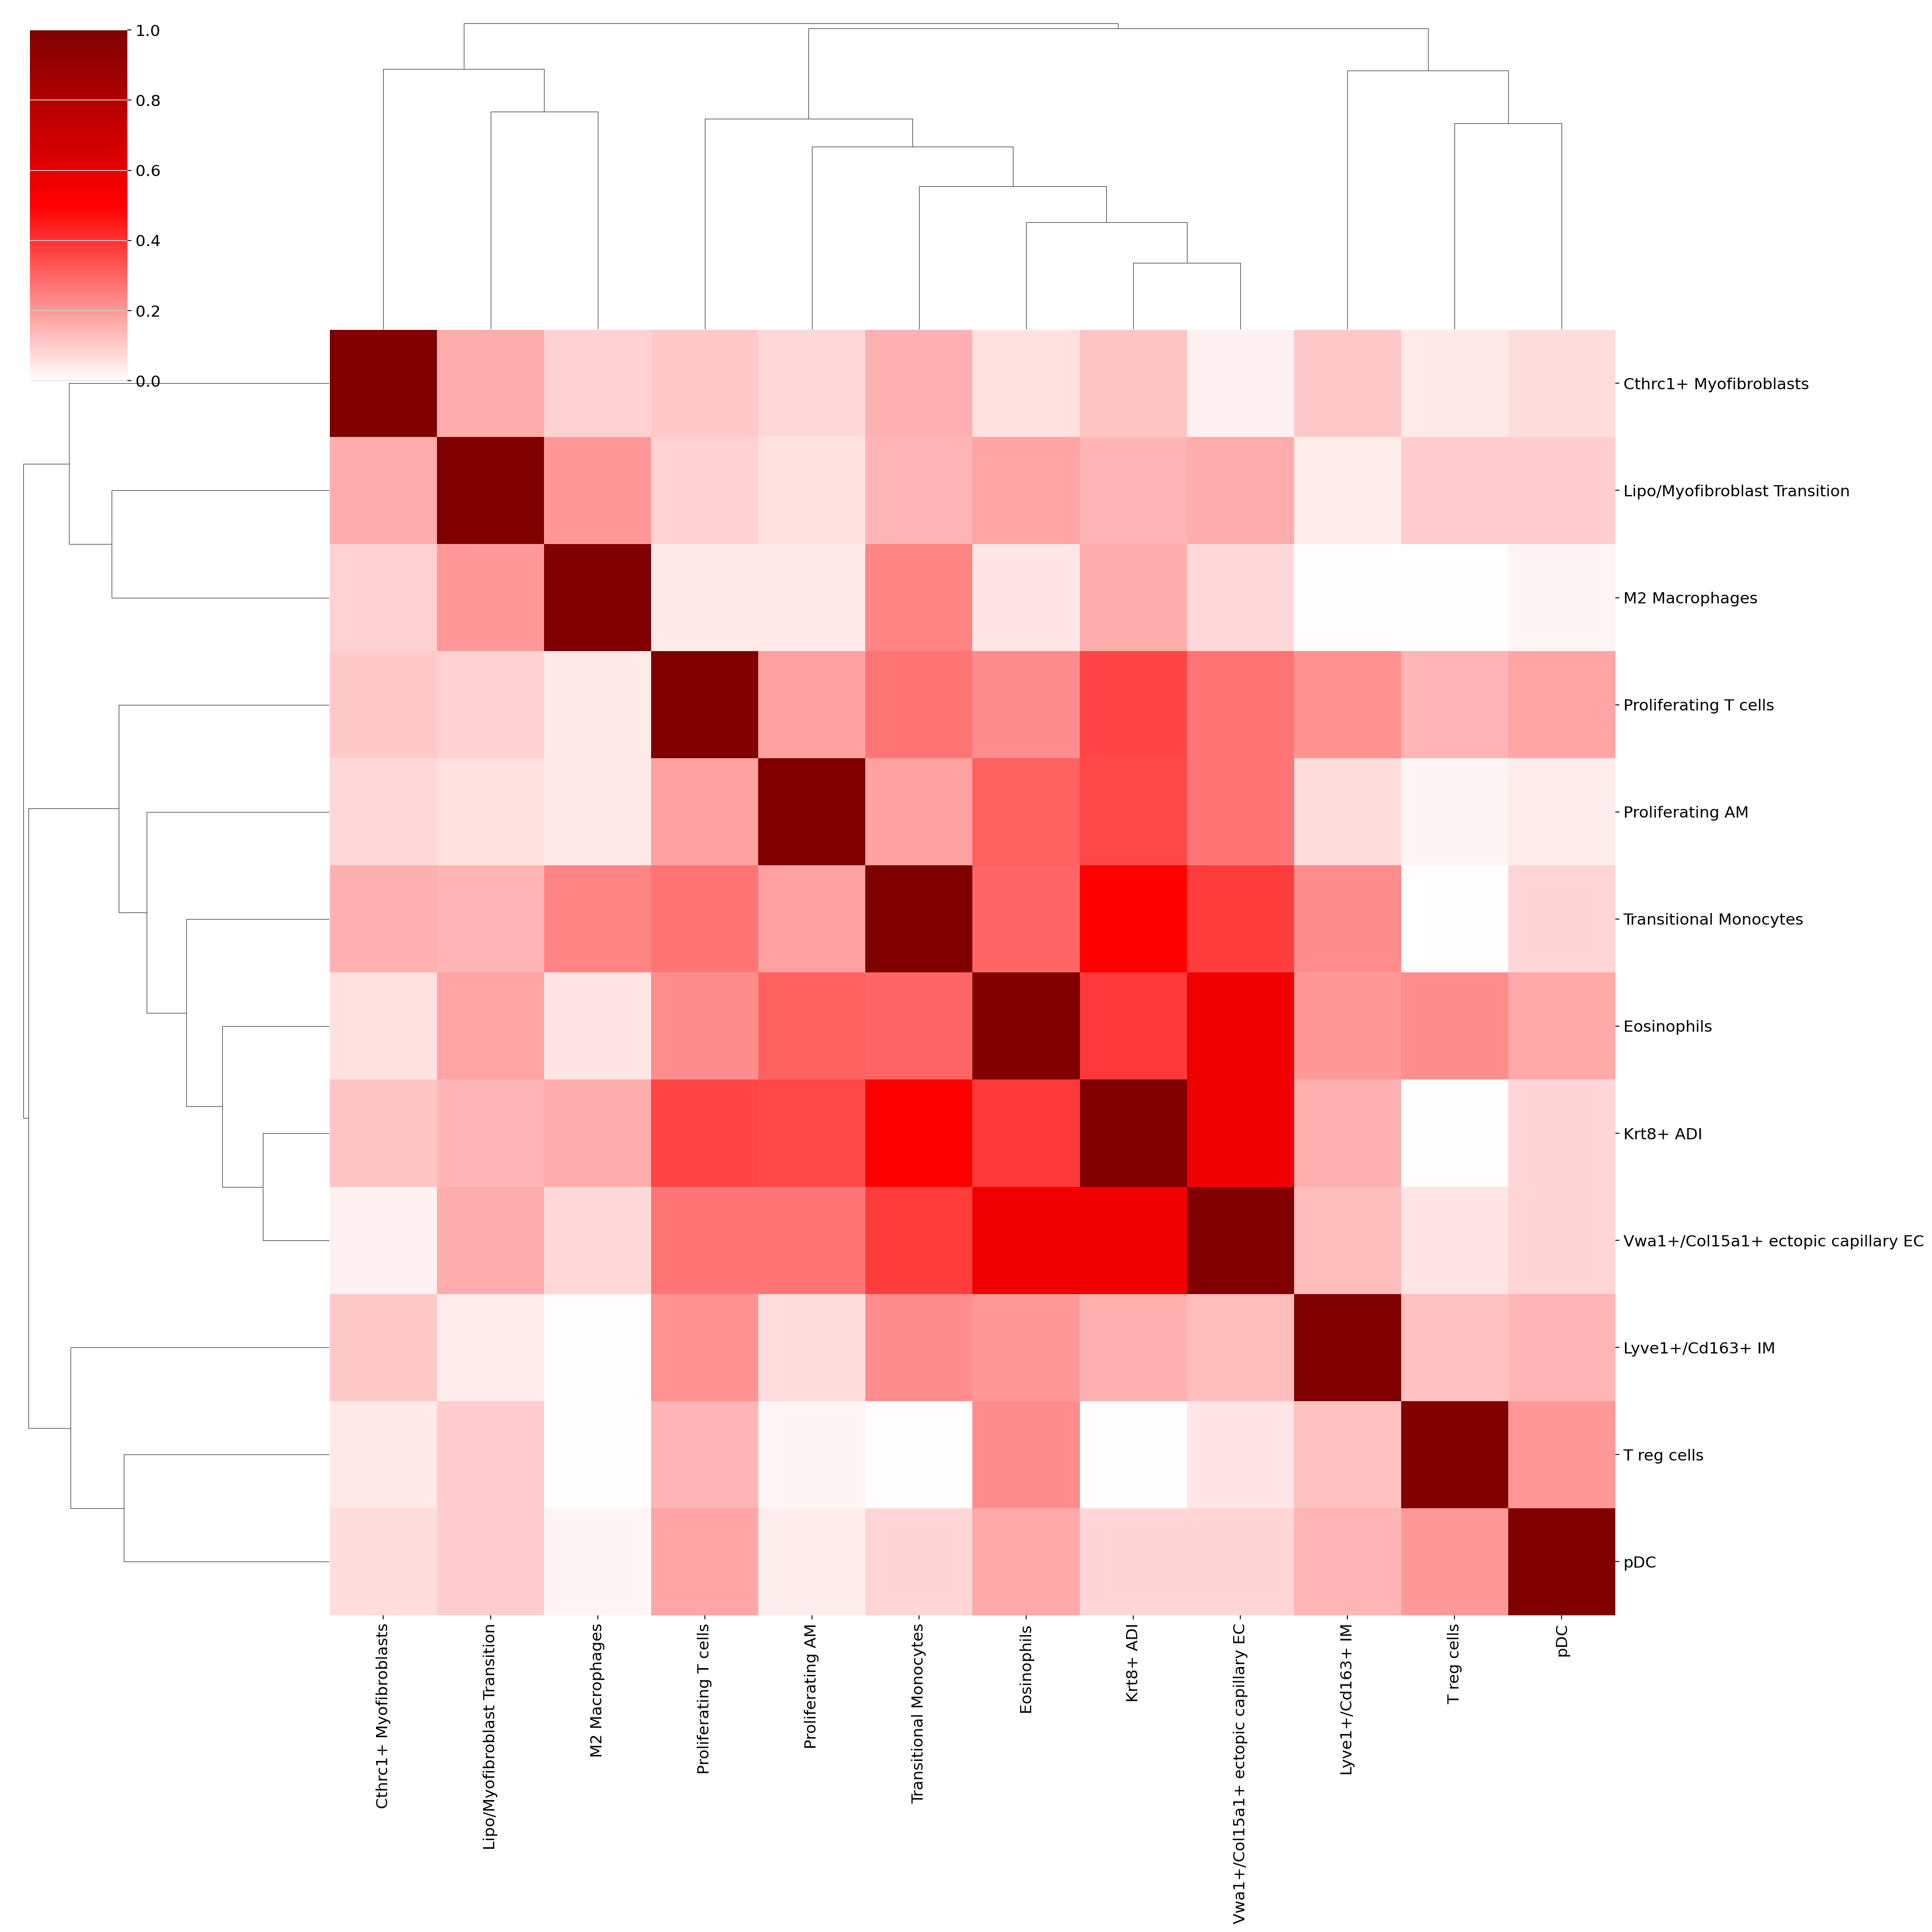

In [25]:
## correlogram 
plt.figure(figsize=(24, 24))
g = sb.clustermap(corr_matrix,
                  method='average',
                  metric='correlation',
                  cmap='seismic',
                  vmin=0, vmax=1,
                  center=0,
                  linewidths=0,
                  linecolor=None, 
                  figsize=(24, 24)
                 )
g.ax_heatmap.grid(False)
g.savefig(fig_dir + 'cell2location_correlogram_pearson_cell_types_of_interest_filtered.pdf', format='pdf', bbox_inches='tight')
plt.show()